Target mapping: {'Q1': np.int64(0), 'Q2': np.int64(1), 'Q3': np.int64(2), 'Q4': np.int64(3)}


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:26:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy (XGBoost with Decision Tree base): 0.5637393767705382

Classification Report:
               precision    recall  f1-score   support

          Q1       0.73      0.66      0.69      2263
          Q2       0.46      0.44      0.45      1909
          Q3       0.44      0.47      0.45      1722
          Q4       0.61      0.68      0.64      1519

    accuracy                           0.56      7413
   macro avg       0.56      0.56      0.56      7413
weighted avg       0.57      0.56      0.56      7413



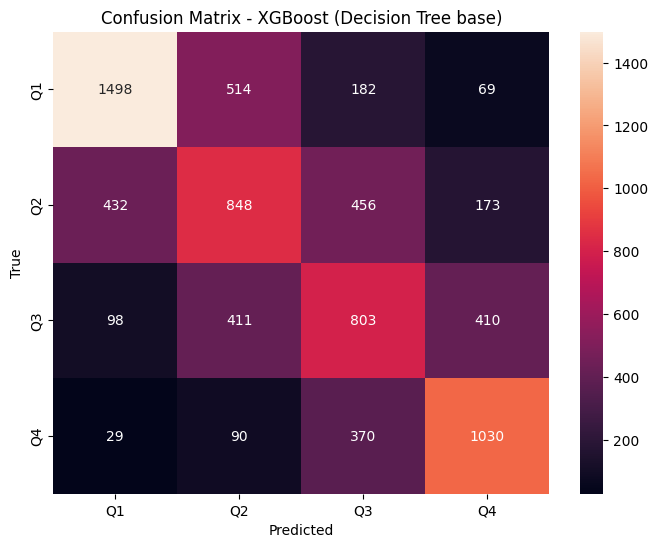

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:26:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:26:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:27:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:27:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

CV Accuracy (10-fold): 0.5717 (+/- 0.0104)


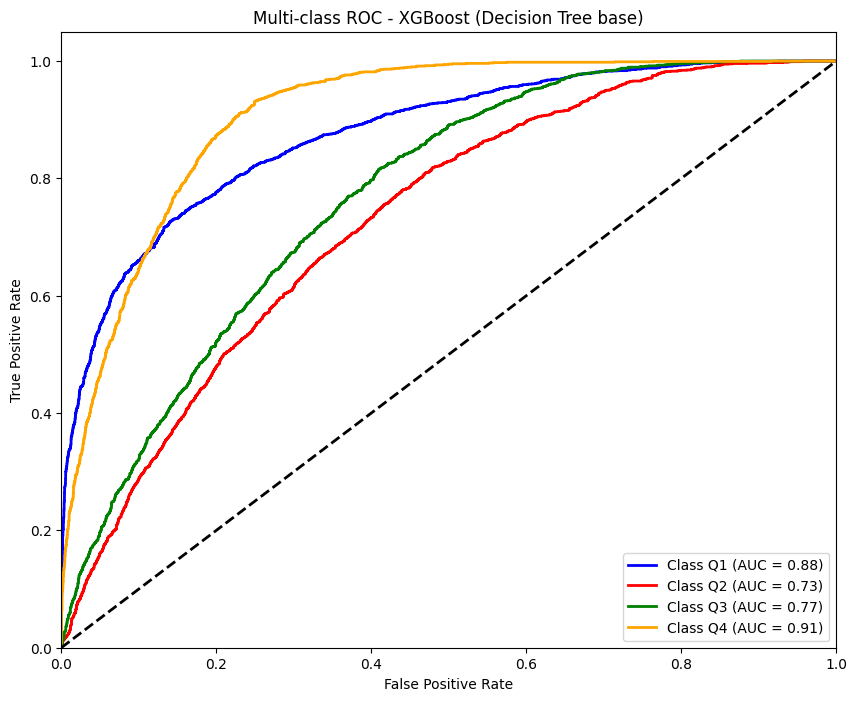

In [1]:
# ========================
# 1. Instalasi dan Impor
# ========================
!pip install xgboost yellowbrick -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# ========================
# 2. Baca Data (perhatikan koma desimal)
# ========================
dt = pd.read_csv('28.csv', decimal=',')   # mengubah "62,937" → 62.937
dt.dropna(inplace=True)                  # hilangkan baris dengan missing (Publisher)

# ========================
# 3. Encode Target (SJR Best Quartile)
# ========================
le = LabelEncoder()
dt['SJR Best Quartile_enc'] = le.fit_transform(dt['SJR Best Quartile'])
print("Target mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# ========================
# 4. Fitur dan Target
# ========================
feature_cols = ['H index', 'Total Docs. (2020)', 'Total Docs. (3years)',
                'Total Refs.', 'Total Cites (3years)',
                'Citable Docs. (3years)', 'Cites / Doc. (2years)',
                'Ref. / Doc.']
X = dt[feature_cols].values
y = dt['SJR Best Quartile_enc'].values

# ========================
# 5. Split Data (stratified)
# ========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=10
)

# Standarisasi (opsional, XGBoost tidak memerlukan scaling, namun tetap aman)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ========================
# 6. XGBoost dengan base estimator Decision Tree (default)
#    booster='gbtree' adalah default, menggunakan pohon keputusan
# ========================
xgb = XGBClassifier(
    n_estimators=500,
    random_state=0,
    use_label_encoder=False,
    eval_metric='mlogloss',
    booster='gbtree'   # eksplisit menyatakan decision tree sebagai base learner
)

xgb.fit(X_train_scaled, y_train)

# ========================
# 7. Evaluasi pada Test Set
# ========================
y_pred = xgb.predict(X_test_scaled)

print("Accuracy (XGBoost with Decision Tree base):", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred,
                                                          target_names=le.classes_))

# Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - XGBoost (Decision Tree base)')
plt.show()

# ========================
# 8. Cross-Validation dengan Pipeline
# ========================
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBClassifier(n_estimators=500, random_state=0,
                          use_label_encoder=False, eval_metric='mlogloss',
                          booster='gbtree'))
])

cv = KFold(n_splits=10, shuffle=True, random_state=1)
cv_scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
print(f"CV Accuracy (10-fold): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# ========================
# 9. ROC AUC (multi-class)
# ========================
# Binarize target untuk ROC
y_test_bin = label_binarize(y_test, classes=np.unique(y))
n_classes = y_test_bin.shape[1]
y_score = xgb.predict_proba(X_test_scaled)

fpr = dict()
tpr = dict()
roc_auc_dict = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc_dict[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10,8))
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown'][:n_classes]
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {le.classes_[i]} (AUC = {roc_auc_dict[i]:.2f})')
plt.plot([0,1],[0,1], 'k--', lw=2)
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC - XGBoost (Decision Tree base)')
plt.legend(loc="lower right")
plt.savefig('roc_auc_xgb_dt.png')
plt.show()